In [2]:

import pandas as pd
import geemap
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import json
SHAPEFILE_PATH = "/home/desy/rift-waters/dataset/bounderies/kenya_wards/kenya_wards.shp"

# Or load directly from a public URL (Kenya wards from HDX)
# SHAPEFILE_PATH = "https://data.humdata.org/dataset/..."  

# Ward names to highlight (Baringo lakeshore wards)
LAKESHORE_WARDS = [
    'Kampi ya Samaki',
    'Salabani', 
    'Ilchamus',
    'Ng\'ambo',
    'Mukutani',
    'Marigat'
]

# ============================================
# LOAD AND PROCESS SHAPEFILE
# ============================================

# Read shapefile with geopandas
try:
    gdf = gpd.read_file(SHAPEFILE_PATH)
    print(f"✅ Loaded shapefile with {len(gdf)} features")
    print(f"   CRS: {gdf.crs}")
    print(f"   Columns: {list(gdf.columns)}")
except Exception as e:
    print(f"❌ Error loading shapefile: {e}")
    print("💡 Tip: Make sure the path is correct and all shapefile components exist")
    raise

# Identify the name column (common variations)


g_df = pd.DataFrame(gdf)
g_df.head()
# Convert to GEE-compatible format (WGS84)



✅ Loaded shapefile with 1450 features
   CRS: EPSG:4326
   Columns: ['gid', 'pop2009', 'county', 'subcounty', 'ward', 'uid', 'scuid', 'cuid', 'geometry']


,gid,pop2009,county,subcounty,ward,uid,scuid,cuid,geometry
0,241,17431.0,ISIOLO,Isiolo Sub County,WABERA,rIdiIpv9fBt,I2LYLqKU6AW,bzOfj0iwfDH,"POLYGON ((37.59968 0.40029, 37.59976 0.40004, ..."
1,1455,18755.0,Migori,Rongo Sub County,North Kamagambo Ward,QC41mItjIzF,fT37q3rXQ35,fVra3Pwta0Q,"POLYGON ((34.59938 -0.65054, 34.60006 -0.65069..."
2,1456,27756.0,Migori,Rongo Sub County,Central Kamagambo Ward,M8rGveWTIMm,fT37q3rXQ35,fVra3Pwta0Q,"POLYGON ((34.61175 -0.73357, 34.61183 -0.73357..."
3,1457,27179.0,Migori,Rongo Sub County,South Kamagambo Ward,DABObbHgPMX,fT37q3rXQ35,fVra3Pwta0Q,"POLYGON ((34.61751 -0.87293, 34.6175 -0.87294,..."
4,1458,22874.0,Migori,Awendo Sub County,North Sakwa Ward,EmSsP2C6A3h,ka9Uv3Ckcbd,fVra3Pwta0Q,"POLYGON ((34.55349 -0.75193, 34.55364 -0.75195..."


In [ ]:
mukutani = g_df.column[g_df.isin(["WABERA"]).any()].tolist()
mukutani

In [31]:
columns = ["ward", "geometry"]


geometry = g_df["geometry"]

ward_geometry = g_df.drop(["gid", "pop2009","uid", "scuid","cuid"], axis=1)

ward_geometry

#g1 = str(geometry[0])



,county,subcounty,ward,geometry
0,ISIOLO,Isiolo Sub County,WABERA,"POLYGON ((37.59968 0.40029, 37.59976 0.40004, ..."
1,Migori,Rongo Sub County,North Kamagambo Ward,"POLYGON ((34.59938 -0.65054, 34.60006 -0.65069..."
2,Migori,Rongo Sub County,Central Kamagambo Ward,"POLYGON ((34.61175 -0.73357, 34.61183 -0.73357..."
3,Migori,Rongo Sub County,South Kamagambo Ward,"POLYGON ((34.61751 -0.87293, 34.6175 -0.87294,..."
4,Migori,Awendo Sub County,North Sakwa Ward,"POLYGON ((34.55349 -0.75193, 34.55364 -0.75195..."
...,...,...,...,...
1445,NANDI,Mosop Sub County,Kabiyet Ward,"POLYGON ((35.07272 0.48254, 35.07311 0.48242, ..."
1446,NANDI,Mosop Sub County,Kabisaga Ward,"POLYGON ((35.12456 0.49184, 35.12494 0.49106, ..."
1447,LAIKIPIA,Laikipia West Sub County,Githiga Ward,"POLYGON ((36.35377 0.4247, 36.35307 0.41684, 3..."
1448,KERICHO,Bureti Sub County,Kapkatet Ward,"POLYGON ((35.19631 -0.57623, 35.1968 -0.57798,..."


In [40]:
baringo_wards = g_df[g_df['county'].str.contains('baringo', case=False, na=False)]

baringo_wards.reset_index()

,index,gid,pop2009,county,subcounty,ward,uid,scuid,cuid,geometry
0,814,781,23669.0,BARINGO,Tiaty Sub County,Tirioko Ward,HTbw8gm6kms,Mk4bMOSMRTB,vvOK1BxTbet,"POLYGON ((35.78413 1.65248, 35.78468 1.65225, ..."
1,815,782,19499.0,BARINGO,Tiaty Sub County,Kolowa Ward,LTWLjOZQMqk,Mk4bMOSMRTB,vvOK1BxTbet,"POLYGON ((35.70665 1.25949, 35.70741 1.2594, 3..."
2,816,783,14572.0,BARINGO,Tiaty Sub County,Ribkwo Ward,XLsFzNATUQ2,Mk4bMOSMRTB,vvOK1BxTbet,"POLYGON ((36.00498 1.2178, 36.00635 1.21679, 3..."
3,817,784,21947.0,BARINGO,Tiaty Sub County,Silale Ward,k2oUoGgQ9Nd,Mk4bMOSMRTB,vvOK1BxTbet,"POLYGON ((36.17553 1.16709, 36.17623 1.16623, ..."
4,818,785,13885.0,BARINGO,Tiaty Sub County,Loiyamorok Ward,A7kJTCLxqNq,Mk4bMOSMRTB,vvOK1BxTbet,"POLYGON ((36.30094 0.98225, 36.29982 0.98113, ..."
5,923,802,27793.0,BARINGO,Mogotio Sub County,Mogotio Ward,duv5obCpRzb,k5sxmlXAtIg,vvOK1BxTbet,"POLYGON ((35.79601 0.26356, 35.79682 0.26134, ..."
6,924,803,16508.0,BARINGO,Mogotio Sub County,Emining Ward,uhTYg7CLmOd,k5sxmlXAtIg,vvOK1BxTbet,"POLYGON ((35.9982 0.38905, 35.99818 0.38891, 3..."
7,925,804,16658.0,BARINGO,Mogotio Sub County,Kisanana Ward,LYDEE54oZAu,k5sxmlXAtIg,vvOK1BxTbet,"POLYGON ((36.15457 0.30108, 36.17389 0.29963, ..."
8,926,805,21140.0,BARINGO,Koibatek Sub County,Lembus Ward,KUL5AR13rwy,Yl9UDBnDvvW,vvOK1BxTbet,"POLYGON ((35.69401 0.17245, 35.68904 0.16656, ..."
9,927,806,20207.0,BARINGO,Koibatek Sub County,Lembus kwen Ward,YoFhsT3n9Ln,Yl9UDBnDvvW,vvOK1BxTbet,"POLYGON ((35.71915 0.18396, 35.71968 0.18392, ..."


In [28]:
import re

coords_str = re.search(r'\(\((.*?)\)\)', g1).group(1)
# Split into coordinate pairs
coord_pairs = coords_str.split(', ')

# Convert to list of [lon, lat] lists for Earth Engine
coordinates = []
for pair in coord_pairs:
    lon, lat = pair.split()
    coordinates.append([float(lon), float(lat)])

print(coordinates)

[[37.59967981409519, 0.400293860100015], [37.599763430779575, 0.4000430364218223], [37.600125771842166, 0.3966151015730243], [37.60015902152282, 0.39662240991905], [37.60022569682275, 0.3959916260720353], [37.60037807179375, 0.3945500834009078], [37.60205660879843, 0.3811674148202594], [37.60243755530174, 0.3781998250385333], [37.60304922935414, 0.3734348493041792], [37.604668646290314, 0.3608195006594044], [37.60496563915149, 0.3585059076939012], [37.60512423340558, 0.3586287137414517], [37.60531926722481, 0.3567733009807256], [37.605608861897245, 0.3540183043410122], [37.60585769577278, 0.3516510791721836], [37.60585775377392, 0.3516505232216527], [37.60175961256545, 0.3470500473738517], [37.598471144995074, 0.3433584914986693], [37.59456428971912, 0.3389727485220643], [37.59006429825708, 0.3339211649209032], [37.5905193685027, 0.3331981632908445], [37.58977998242471, 0.3337133504582742], [37.589770408229484, 0.3337200208648771], [37.588890552155284, 0.3327816105385428], [37.58859881

In [50]:
ee.Initialize(project='riftwaters')

def mask_edge(image):
  edge = image.lt(-30.0)
  masked_image = image.mask().And(edge.Not())
  return image.updateMask(masked_image).clip(ROI)



ROI = ee.Geometry.Polygon(coordinates)

img_vv = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(ROI)
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .select('VV')
    .map(mask_edge)
)

desc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).median()
asc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')).median()

geemap.ee_export_image(
                asc, filename=str("wambera.tif"), scale=30, region=ROI
            )


# m = geemap.Map()
# m.set_center(34.64776539273558, 0.7346345910716864)
# #m.add_layer(asc, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
# m.add_layer(desc, {'min': -25, 'max': 5}, 'Multi-T Mean DESC', True)


Generating URL ...
Please wait ...
Data downloaded to /home/desy/rift-waters/notebooks/wambera.tif


(277, 122)
-22.49549847384155 12.574191128326058


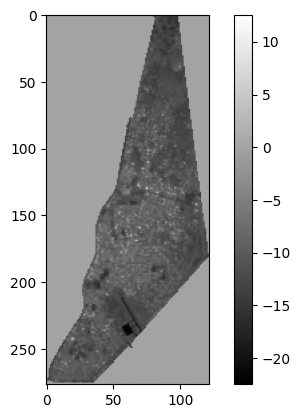

In [51]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("wambera.tif") as src:
    image = src.read(1)
    
    print(image.shape)
    print(image.min(), image.max())
    plt.imshow(image, cmap='gray')
    plt.colorbar()
    plt.show()

In [4]:

def geodataframe_to_ee(gdf):
    """Convert GeoDataFrame to Earth Engine FeatureCollection"""
    features = []
    for idx, row in gdf.iterrows():
        geom = json.loads(row.geometry.__geo_interface__)
        # Remove properties that aren't serializable
        props = row.drop('geometry').to_dict()
        props = {k: v for k, v in props.items() 
                if isinstance(v, (str, int, float, bool, type(None)))}
        feature = ee.Feature(ee.Geometry(geom), props)
        features.append(feature)
    return ee.FeatureCollection(features)

wards_fc = geodataframe_to_ee(gdf)

TypeError: the JSON object must be str, bytes or bytearray, not dict